# EDA for cohesin cofactors expression over different tissues or timepoints

- last updated: 11/4/2025

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

# rapids-singlecell
import cupy as cp
import rapids_singlecell as rsc

In [2]:
# figure parameter setting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
mpl.rcParams.update(mpl.rcParamsDefault) #Reset rcParams to default

# Editable text and proper LaTeX fonts in illustrator
# matplotlib.rcParams['ps.useafm'] = True
# Editable fonts. 42 is the magic number
mpl.rcParams['pdf.fonttype'] = 42
sns.set(style='whitegrid', context='paper')
# Set default DPI for saved figures
mpl.rcParams['savefig.dpi'] = 600

# Plotting style function (run this before plotting the final figure)
def set_plotting_style():
    plt.style.use('seaborn-paper')
    plt.rc('axes', labelsize=12)
    plt.rc('axes', titlesize=12)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rc('legend', fontsize=10)
    plt.rc('text.latex', preamble=r'\usepackage{sfmath}')
    plt.rc('xtick.major', pad=2)
    plt.rc('ytick.major', pad=2)
    plt.rc('mathtext', fontset='stixsans', sf='sansserif')
    plt.rc('figure', figsize=[8,8])
    plt.rc('svg', fonttype='none')

In [3]:
import logging
# Suppress INFO-level logs for the entire logger
logging.getLogger().setLevel(logging.WARNING)

In [4]:
# define the figure path
import os
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/umaps/"
os.makedirs(figpath, exist_ok=True)
sc.settings.figdir = figpath

In [5]:
# load the master adata object (multiome, all timepoints, low-quality cells were filtered out)
# NOTE that this adata has "RNA" counts in the counts layer
adata = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_master_filtered.h5ad")
adata

AnnData object with n_obs × n_vars = 94562 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'

## Check the known markers from zebrafish biology experts

In [3]:
markers_15somites = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/table_marker_genes/marker_genes_15somites.csv", index_col=0)
markers_15somites.head()

,cell_annotation,timepoint,annotation_human_readable,marker genes,Unnamed: 5,Unnamed: 6
leiden,,,,,,
1,somite_lrrc17_comp_ripply1,15somite,somite,lrrc17,comp,ripply1
2,optic_vesicle_rx1_vsx2,15somite,optic vesicle,rx1,vsx2,NaN
3,paraxial_mesoderm_tbx16_myf5_hes6,15somite,paraxial mesoderm,tbx16,myf5,hes6
4,neural_crest_crestin_ednrab_dlx2a,15somite,neural crest,crestin,ednrab,dlx2a
5,periderm_cldni_cfl1l,15somite,periderm,cldni,cfl1l,NaN


In [4]:
markers_15somites.columns

Index(['cell_annotation', 'timepoint', 'annotation_human_readable',
       'marker genes', 'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')

In [6]:
list_markers = []

for col_name in ["marker genes", "Unnamed: 5", "Unnamed: 6"]:
    list_temp = markers_15somites[col_name].tolist()
    list_markers = list_markers + list_temp

list_unique_markers = np.unique(list_markers)
list_unique_markers

array(['acy3', 'anxa4', 'apobec2a', 'atp1b1b', 'bricd5', 'cebpa', 'cfl1l',
       'chd17', 'cldn15a', 'cldnc', 'cldni', 'comp', 'cpox', 'crestin',
       'ctslb', 'dlx2a', 'ednrab', 'elavl3', 'emilin3a', 'etnk1', 'etv5a',
       'fezf1', 'fli1b', 'foxa2', 'foxg1a', 'foxi3b', 'gata1a', 'gata5',
       'hand2', 'hbbe1', 'hes6', 'hoxd4a', 'icn2', 'irx7', 'jam2a',
       'kdrl', 'krt17', 'loxl5b', 'lrrc17', 'mcf2lb', 'myb', 'myf5',
       'myh7', 'myl1', 'myog', 'nan', 'nid1b', 'olig3', 'osr1', 'pitx3',
       'pkd1b', 'ppl', 'prrx1', 'ripply1', 'rx1', 'rxrga', 'scg3',
       'sec61a1l', 'sema3aa', 'shha', 'shhb', 'sncb', 'sox1b', 'spi1b',
       'stmn1b', 'surf4l', 'tbx16', 'tbx3b', 'tnnt2a', 'ttn1', 'unc45b',
       'vegfaa', 'vsx2'], dtype='<U32')

In [7]:
np.unique(list_markers)

array(['acy3', 'anxa4', 'apobec2a', 'atp1b1b', 'bricd5', 'cebpa', 'cfl1l',
       'chd17', 'cldn15a', 'cldnc', 'cldni', 'comp', 'cpox', 'crestin',
       'ctslb', 'dlx2a', 'ednrab', 'elavl3', 'emilin3a', 'etnk1', 'etv5a',
       'fezf1', 'fli1b', 'foxa2', 'foxg1a', 'foxi3b', 'gata1a', 'gata5',
       'hand2', 'hbbe1', 'hes6', 'hoxd4a', 'icn2', 'irx7', 'jam2a',
       'kdrl', 'krt17', 'loxl5b', 'lrrc17', 'mcf2lb', 'myb', 'myf5',
       'myh7', 'myl1', 'myog', 'nan', 'nid1b', 'olig3', 'osr1', 'pitx3',
       'pkd1b', 'ppl', 'prrx1', 'ripply1', 'rx1', 'rxrga', 'scg3',
       'sec61a1l', 'sema3aa', 'shha', 'shhb', 'sncb', 'sox1b', 'spi1b',
       'stmn1b', 'surf4l', 'tbx16', 'tbx3b', 'tnnt2a', 'ttn1', 'unc45b',
       'vegfaa', 'vsx2'], dtype='<U32')

In [8]:
markers_30somites = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/table_marker_genes/marker_genes_30somites.csv", index_col=0)
markers_30somites.head()

,leiden,cell_annotation,timepoint,version,annotation_human_readable,marker genes,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,zfa_id,is_cell_type,is_in_zfin,comments,ml reply,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,0,diencephalon_pax6a_fgfr3_sox2_foxb1a,30somite,before_aug_9,diencephalon,pax6a,fgfr3,sox2,foxb1a,NaN,...,ZFA:0000101,this is not a cell type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,0,diencephalon_pax6a_fgfr3_sox2_foxb1a,30somite,aug_9,diencephalon,pax6a,fgfr3,sox2,foxb1a,NaN,...,ZFA:0000101,this is not a cell type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,optic_cup_foxg1b_rx1_pax10,30somite,before_aug_9,optic cup,foxg1b,rx1,pax10,NaN,NaN,...,ZFA:0001202,this is not a cell type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,optic_cup_foxg1b_rx1_pax10,30somite,aug_9,optic cup,foxg1b,rx1,pax10,NaN,NaN,...,ZFA:0001202,this is not a cell type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2,hematopoietic_system_hbbe2_slc4a1a_gata1a,30somite,before_aug_9,hematopoietic system,hbbe2,slc4a1a,gata1a,NaN,NaN,...,ZFA:0005023,this is not a cell type,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
list_markers = []

for col_name in ["marker genes", "Unnamed: 7", "Unnamed: 8","Unnamed: 9","Unnamed: 10","Unnamed: 11"]:
    list_temp = markers_30somites[col_name].tolist()
    list_markers = list_markers + list_temp

list_unique_markers_30 = np.unique(list_markers)
list_unique_markers_30

array(['actc1a', 'agr1', 'agr2', 'ak1', 'anxa1c', 'apeob', 'apobec2a',
       'atoh1a', 'atp1b1a', 'bmp2b', 'bmp6', 'cd63', 'cdh1', 'cdh5',
       'cebpa', 'cebpb', 'cfl1l', 'cldn7b', 'cldnh', 'col9a2', 'crestin',
       'ctslb', 'cxcr3.2', 'dct', 'desma', 'dlx3b', 'dusp2', 'egr2b',
       'elavl3', 'en1a', 'en2a', 'en2b', 'eno3', 'evpla', 'fezf1',
       'fezf2', 'fgf8a', 'fgfr3', 'fibina', 'foxa2', 'foxb1a', 'foxc1b',
       'foxd3', 'foxe3', 'foxg1a', 'foxg1b', 'fxr2', 'gata1a', 'gata5',
       'gata6', 'gch2', 'gsnb', 'hand2', 'hbbe2', 'he1.2', 'her15.1',
       'hes6', 'hgfa', 'hoxc13a', 'hsp90aa1.1', 'isl1', 'kdrl', 'lfng',
       'lft1', 'map2', 'meox1', 'mitfa', 'mylz3', 'myo1eb', 'myog', 'nan',
       'nkx6.1', 'ntn1b', 'olig2', 'olig4', 'osr1', 'pah', 'pax10',
       'pax6a', 'pdgfra', 'pitx3', 'plp1a', 'pmela', 'pmp22', 'ppl',
       'prox1a', 'ptx3', 'rac2', 'rx1', 'sema3e', 'shha', 'six1b',
       'six3a', 'slc4a1a', 'sox10', 'sox2', 'sox2b', 'sp8b', 'stm',
       'tbx15',

In [10]:
master_list_markers = list_unique_markers.tolist() + list_unique_markers_30.tolist()
master_list_markers = np.unique(master_list_markers)
master_list_markers

array(['actc1a', 'acy3', 'agr1', 'agr2', 'ak1', 'anxa1c', 'anxa4',
       'apeob', 'apobec2a', 'atoh1a', 'atp1b1a', 'atp1b1b', 'bmp2b',
       'bmp6', 'bricd5', 'cd63', 'cdh1', 'cdh5', 'cebpa', 'cebpb',
       'cfl1l', 'chd17', 'cldn15a', 'cldn7b', 'cldnc', 'cldnh', 'cldni',
       'col9a2', 'comp', 'cpox', 'crestin', 'ctslb', 'cxcr3.2', 'dct',
       'desma', 'dlx2a', 'dlx3b', 'dusp2', 'ednrab', 'egr2b', 'elavl3',
       'emilin3a', 'en1a', 'en2a', 'en2b', 'eno3', 'etnk1', 'etv5a',
       'evpla', 'fezf1', 'fezf2', 'fgf8a', 'fgfr3', 'fibina', 'fli1b',
       'foxa2', 'foxb1a', 'foxc1b', 'foxd3', 'foxe3', 'foxg1a', 'foxg1b',
       'foxi3b', 'fxr2', 'gata1a', 'gata5', 'gata6', 'gch2', 'gsnb',
       'hand2', 'hbbe1', 'hbbe2', 'he1.2', 'her15.1', 'hes6', 'hgfa',
       'hoxc13a', 'hoxd4a', 'hsp90aa1.1', 'icn2', 'irx7', 'isl1', 'jam2a',
       'kdrl', 'krt17', 'lfng', 'lft1', 'loxl5b', 'lrrc17', 'map2',
       'mcf2lb', 'meox1', 'mitfa', 'myb', 'myf5', 'myh7', 'myl1', 'mylz3',
       'my

In [11]:
## NOTE: some genes are missing from the adata.var_names (probably due to the Cellranger-arc mapping isoforms...)
missing_genes = ['acy3', 'apeob', 'chd17', 'hbbe1', 'nan', 'pmp22', 'prrx1', 'ptx3', 'sox2b', 'ttn1']

for gene in missing_genes:
    print("gene ", gene, " is ", gene in (adata.var_names))

gene  acy3  is  False
gene  apeob  is  False
gene  chd17  is  False
gene  hbbe1  is  False
gene  nan  is  False
gene  pmp22  is  False
gene  prrx1  is  False
gene  ptx3  is  False
gene  sox2b  is  False
gene  ttn1  is  False


In [ ]:
master_list_markers = [gene for gene in master_list_markers if gene not in missing_genes]

## Check the annotation levels
- we will create a dictionary to mape the celll types to broader "tissues".

In [6]:
adata.obs["annotation_ML_coarse"].unique().to_list()

['epidermis',
 'pronephros',
 'hindbrain',
 'spinal_cord',
 'neural_optic',
 'neural_floor_plate',
 'neural_crest',
 'PSM',
 'optic_cup',
 'lateral_plate_mesoderm',
 'midbrain_hindbrain_boundary',
 'neural_telencephalon',
 'differentiating_neurons',
 'muscle',
 'fast_muscle',
 'heart_myocardium',
 'somites',
 'NMPs',
 'pharyngeal_arches',
 'floor_plate',
 'hemangioblasts',
 'neural_posterior',
 'tail_bud',
 'endoderm',
 'hematopoietic_vasculature',
 'endocrine_pancreas',
 'hatching_gland',
 'neurons',
 'notochord',
 'enteric_neurons',
 'neural',
 'primordial_germ_cells']

In [46]:
adata[adata.obs["annotation_ML_coarse"]=="floor_plate"].obs["annotation_ML"]

AAACCGGCAGAATGAC-1_1    floor_plate2
AAACGTACAATGAAGC-1_1     floor_plate
AAAGGCTCATGTTGTG-1_1    floor_plate2
AAAGGTTAGGACACTT-1_1    floor_plate2
AACAGCAAGCGAGCGA-1_1     floor_plate
                            ...     
TTTATGGAGAACCTAC-1_7     floor_plate
TTTCATCAGCTACTGG-1_7     floor_plate
TTTCTCACACTAAGAA-1_7     floor_plate
TTTGACTTCAATTACG-1_7     floor_plate
TTTGGCTGTCAAAGGG-1_7     floor_plate
Name: annotation_ML, Length: 3458, dtype: category
Categories (2, object): ['floor_plate', 'floor_plate2']

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


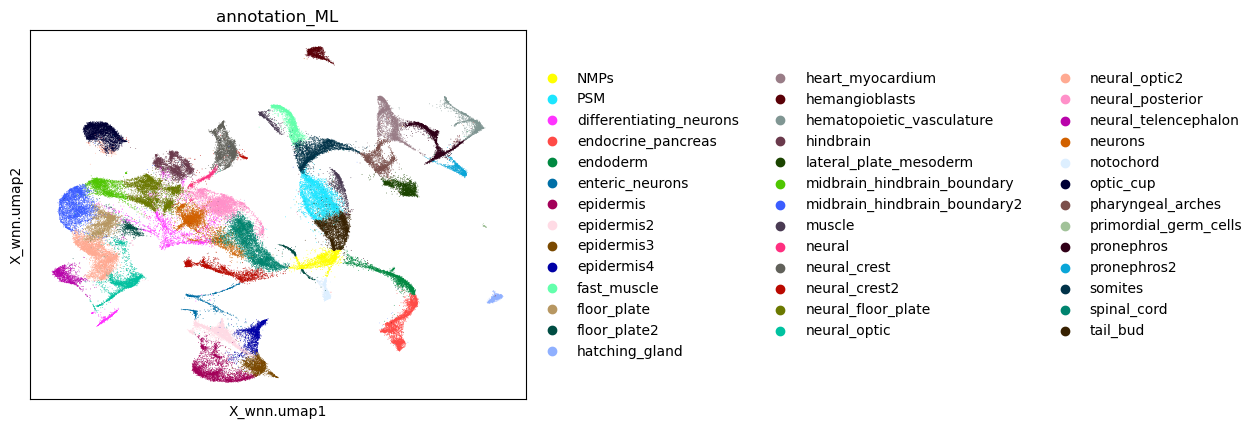

In [47]:
sc.pl.embedding(adata, basis="X_wnn.umap", color="annotation_ML")

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1107: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword

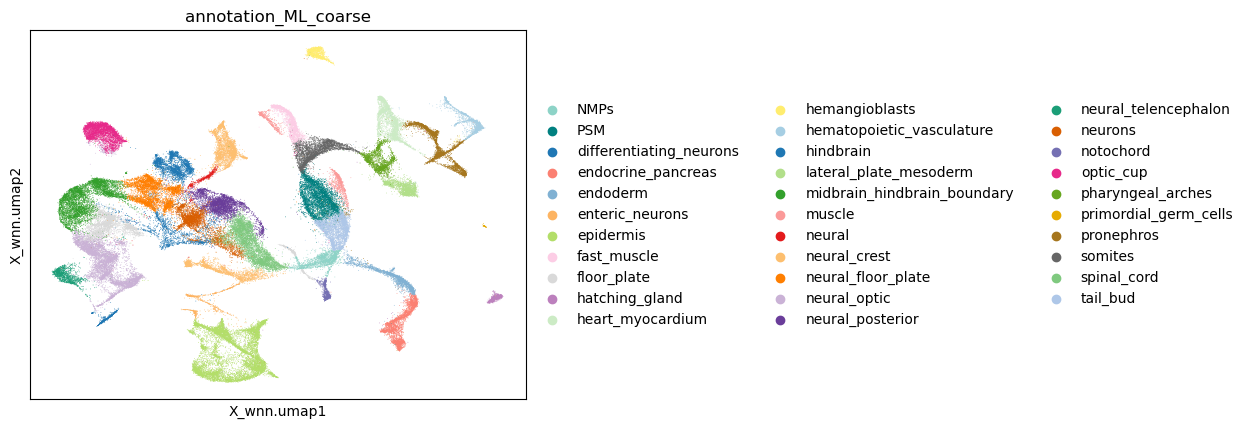

In [59]:
sc.pl.embedding(adata, basis="X_wnn.umap", color="annotation_ML_coarse")

In [7]:
celltype_to_lineage = {
    "CNS": [
        "neural", 
        "neural_optic", 
        "neural_optic2", 
        "neural_posterior", 
        "neural_telencephalon",
        "neurons",
        "hindbrain",
        "midbrain_hindbrain_boundary",
        "midbrain_hindbrain_boundary2",
        "optic_cup",
        "spinal_cord",
        "differentiating_neurons",
        "floor_plate",
        "neural_floor_plate",
        "enteric_neurons",
    ],
    
    "Neural Crest": [
        "neural_crest",
        "neural_crest2"
    ],
    
    "Paraxial Mesoderm": [
        "somites",
        "fast_muscle",
        "muscle",
        "PSM",  # Presomitic mesoderm
        "floor_plate2",
        "NMPs",  # Neuromesodermal progenitors
        "tail_bud", 
        "notochord",
    ],
    
    "Lateral Mesoderm": [
        "lateral_plate_mesoderm",
        "heart_myocardium",
        "hematopoietic_vasculature",
        "pharyngeal_arches",
        "pronephros",
        "pronephros2",
        "hemangioblasts",
        "hatching_gland",
    ],
    
    "Endoderm": [
        "endoderm",
        "endocrine_pancreas",
        # "hatching_gland"
    ],
    
    "Epiderm": [
        "epidermis",
        "epidermis2",
        "epidermis3",
        "epidermis4"
    ],
    
    "Germline": [
        "primordial_germ_cells"
    ],
}

# Display results to user
# tools.display_dataframe_to_user(name="Cell Type to Lineage Mapping", dataframe=pd.DataFrame.from_dict(celltype_to_lineage, orient='index', columns=['Lineage']))
# tools.display_dataframe_to_user(name="Marker Genes for Each Lineage", dataframe=pd.DataFrame.from_dict(marker_genes_by_lineage, orient='index').T)


In [8]:
def map_celltype_to_tissue(cell_type, tissue_dict):
    """
    Maps a cell type to its corresponding tissue group.
    
    Parameters:
    -----------
    cell_type : str
        The cell type to map
    tissue_dict : dict
        Dictionary mapping tissue groups to lists of cell types
        
    Returns:
    --------
    str
        The tissue group the cell type belongs to
    """
    for tissue, cell_types in tissue_dict.items():
        if cell_type in cell_types:
            return tissue
    return "Unknown"  # Return Unknown if cell type not found in dictionary

In [9]:
# Create a new column in adata.obs for tissue groups
adata.obs["tissue"] = adata.obs["annotation_ML"].apply(
    lambda x: map_celltype_to_tissue(x, celltype_to_lineage)
)

# Verify the mapping worked
print(adata.obs["tissue"].value_counts())

CNS                  42391
Paraxial Mesoderm    18581
Lateral Mesoderm     13781
Epiderm               9496
Neural Crest          5270
Endoderm              4956
Germline                87
Name: tissue, dtype: int64


In [12]:
tissue_colors = {
    'CNS': '#DAA520',                    # Golden/orange
    'Endoderm': '#6A5ACD',              # Blue/purple  
    'Epiderm': '#DC143C',               # Red
    'Germline': '#DA70D6',              # Magenta/orchid
    'Lateral Mesoderm': '#228B22',      # Forest green
    'Neural Crest': '#20B2AA',          # Light sea green/teal
    'Paraxial Mesoderm': '#4169E1'      # Royal blue
}

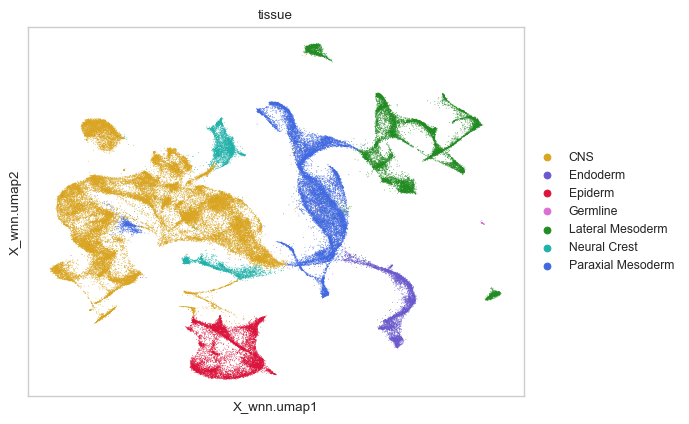

In [13]:
sc.pl.embedding(adata, basis="X_wnn.umap", color="tissue", 
                palette=celltype_colors, save="_tissue.png")

/tmp/ipykernel_1954740/158802269.py:11: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  fig_legend.legend(legend.legendHandles, [t.get_text() for t in legend.get_texts()],


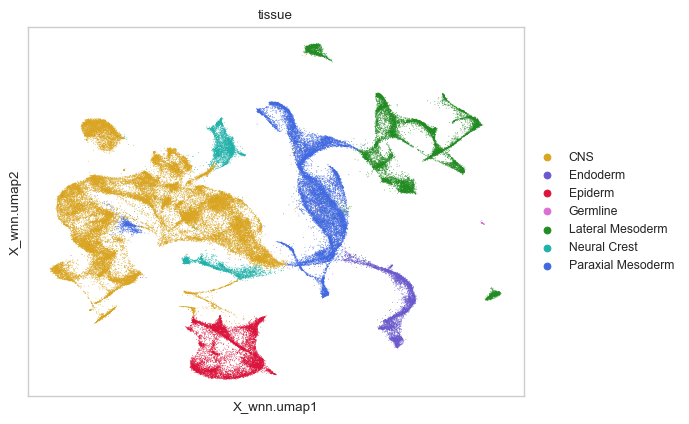

<Figure size 300x400 with 0 Axes>

In [16]:
# First create your plot
sc.pl.embedding(adata, basis="X_wnn.umap", color="tissue", 
                palette=celltype_colors, show=False)

# Get the current figure and extract legend
fig = plt.gcf()
legend = fig.axes[0].get_legend()

# Create new figure with just the legend
fig_legend = plt.figure(figsize=(3, 4))
fig_legend.legend(legend.legendHandles, [t.get_text() for t in legend.get_texts()], 
                  loc='center', frameon=False)
plt.savefig(figpath + 'tissue_legend_only.pdf', dpi=600, bbox_inches='tight')
plt.show()

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


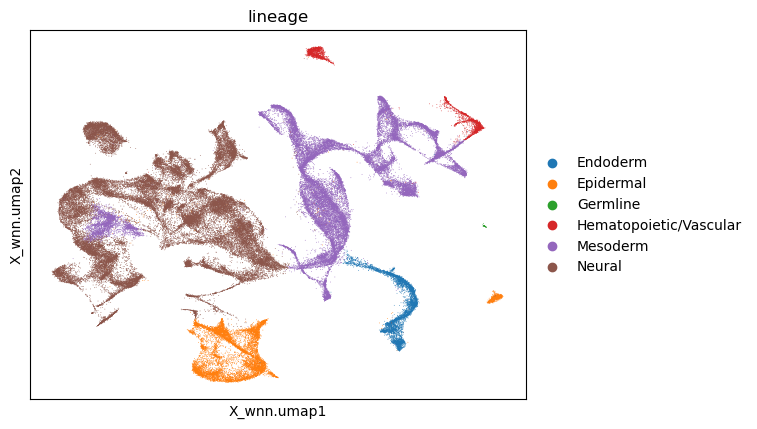

In [20]:
# sc.pl.embedding(adata, basis="X_wnn.umap", color="lineage")

In [28]:
# Define marker genes for each lineage
marker_genes_by_lineage = {
    'Epidermal': ['tp63', 'krt17', 'cdh1', 'tpma'],
    'Neural': ['sox2', 'sox1b', 'pax6a', 'vsx2', 'elavl3', 'olig2'],
    'Neural Crest': ['sox10', 'foxd3', 'tfap2a', 'mitfa', 'dlx2a'],
    'Mesoderm': ['tbxta', 'tbx16', 'meox1', 'myog', 'myf5', 'myl1'],
    'Hematopoietic/Vascular': ['spi1b', 'fli1b', 'gata1a', 'kdrl'],
    'Endoderm': ['foxa2', 'gata6', 'sox32', 'pdgfra'],
    'Germline': ['nanos3', 'vasa', 'dnd1', 'piwil1']
}

# Flatten the marker gene dictionary to get a list of all markers
all_markers = []
for genes in marker_genes_by_lineage.values():
    all_markers.extend(genes)


In [31]:
list_marker_genes = []

for gene in all_markers:
    if gene in adata.var_names:
        list_marker_genes.append(gene)
        
list_marker_genes

['tp63',
 'krt17',
 'cdh1',
 'tpma',
 'sox2',
 'sox1b',
 'pax6a',
 'vsx2',
 'elavl3',
 'olig2',
 'sox10',
 'foxd3',
 'tfap2a',
 'mitfa',
 'dlx2a',
 'tbxta',
 'tbx16',
 'meox1',
 'myog',
 'myf5',
 'myl1',
 'spi1b',
 'fli1b',
 'gata1a',
 'kdrl',
 'foxa2',
 'gata6',
 'sox32',
 'pdgfra',
 'nanos3',
 'dnd1',
 'piwil1']

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided vi

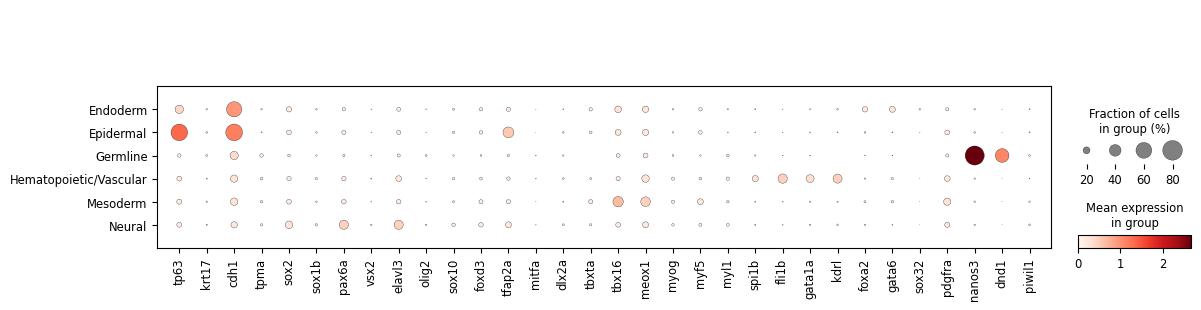

In [32]:
sc.pl.dotplot(adata, var_names = list_marker_genes, groupby="lineage")

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a fu

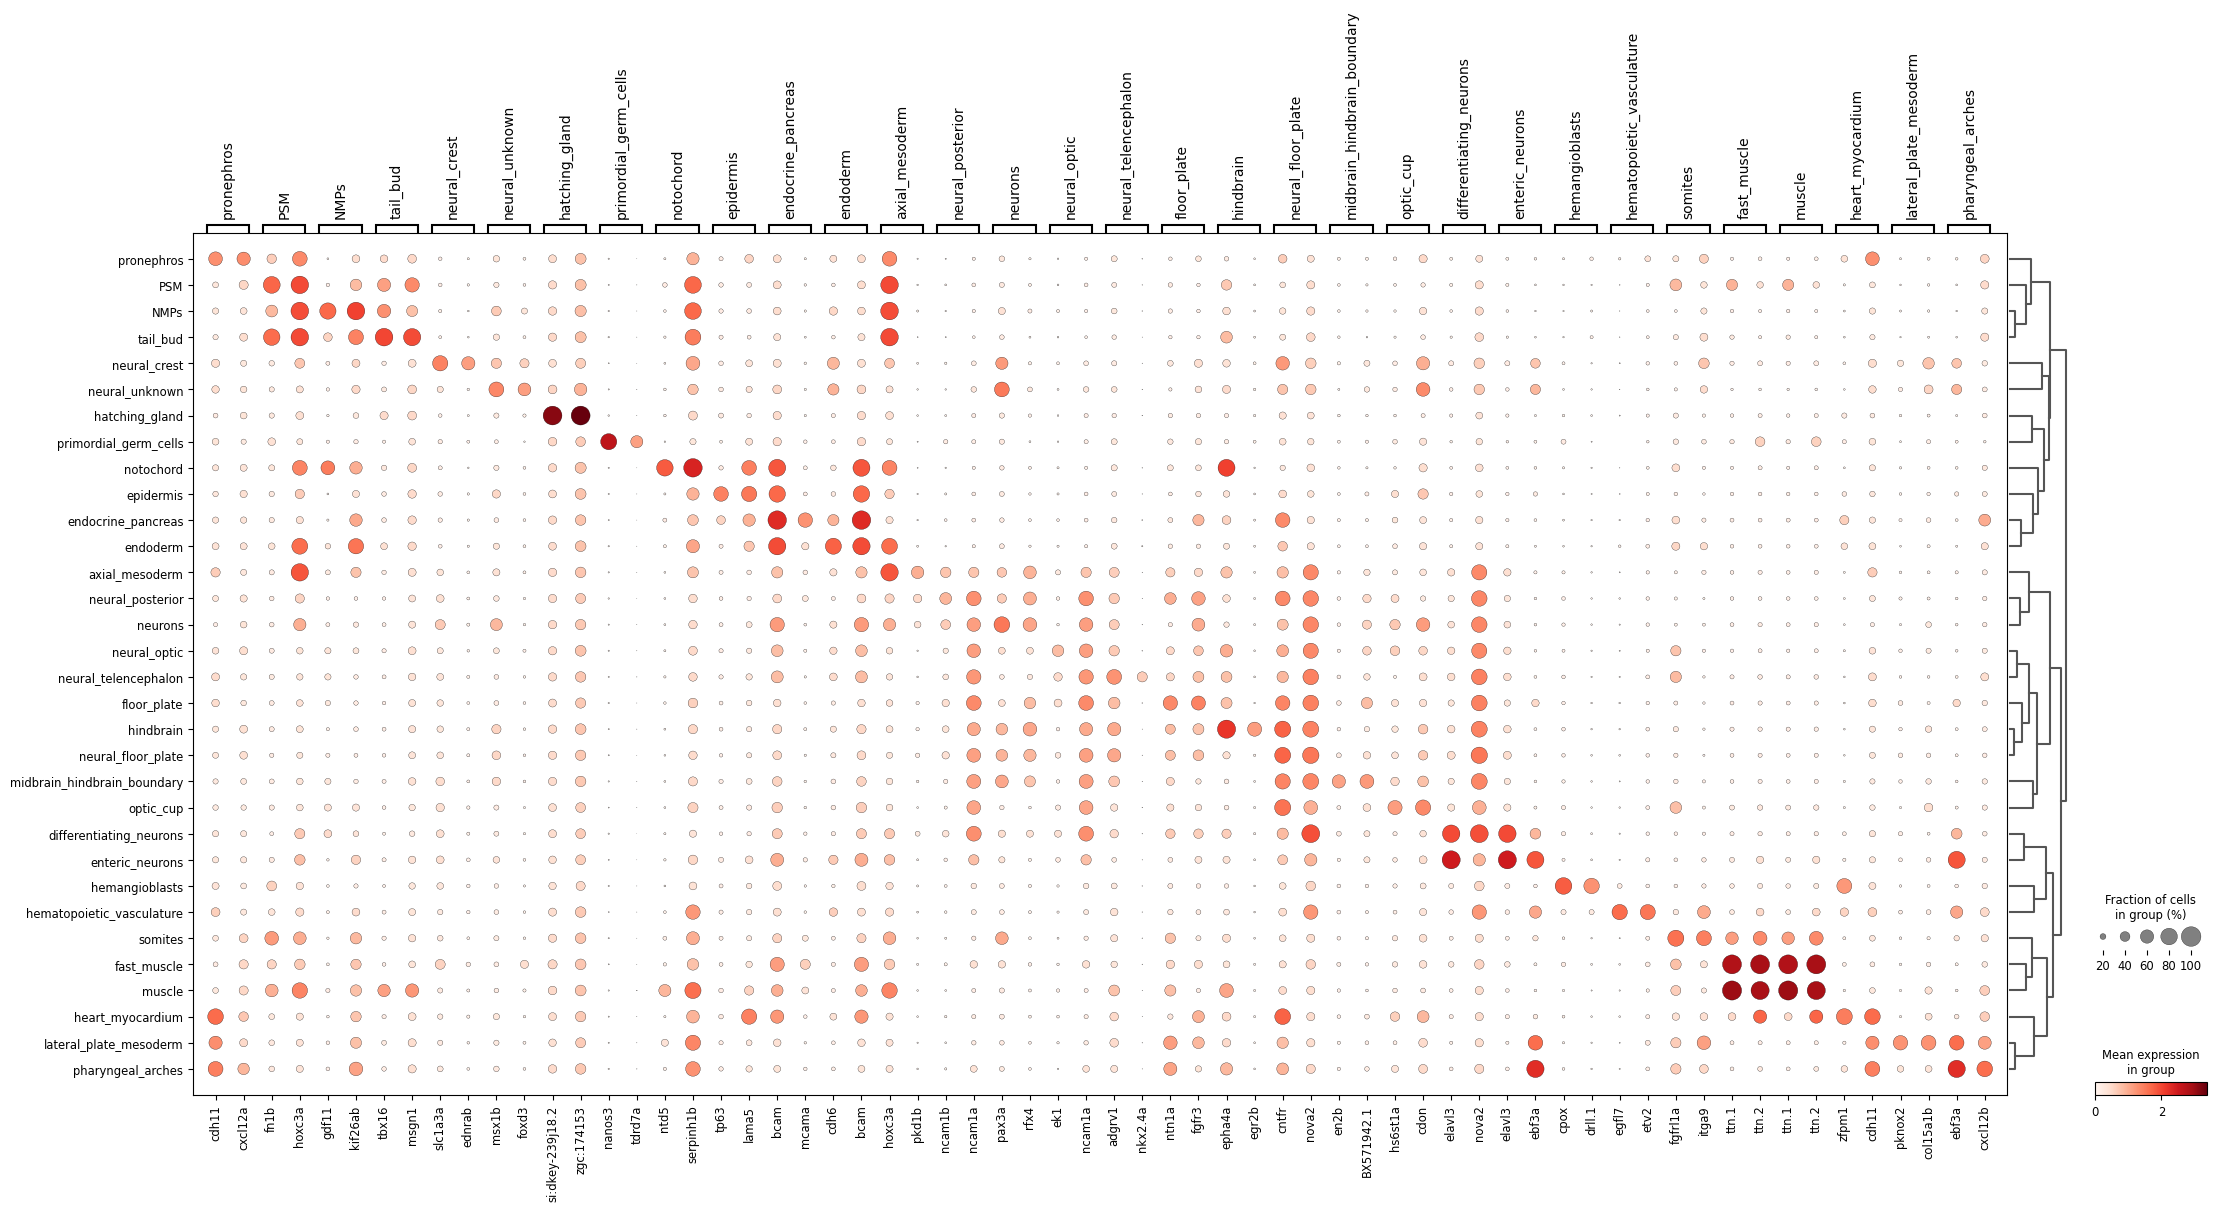

In [57]:
# sc.pl.rank_genes_groups_dotplot(adata, n_genes=2)

In [33]:
sc.tl.rank_genes_groups(adata, groupby="lineage", method = "wilcoxon")

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [ ]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5)

In [40]:
# # Define refined marker genes based on Wilcoxon results and literature
# # refined_marker_genes = {
# #     'Neural': ['sox2', 'neurog1', 'pax6a', 'gli3', 'chl1a'],
# #     'Germline': ['nanos3', 'tdrd7a', 'dnd1'],
# #     'Hematopoietic/Vascular': ['etv2', 'fli1a', 'lmo2', 'tal1'],
# #     'Mesoderm': ['tbx6', 'tbxta', 'msgn1', 'meox1'],
# #     'Endoderm': ['foxa3', 'onecut1', 'nr5a2', 'col2a1a'],
# #     'Epidermal': ['cdh1', 'epcam', 'krt4']
# # }
# refined_marker_genes = {
#     "Endoderm":["fgfrl1b","col2a1a","ptprfa","emid1","nr5a2","ism2a","pawr","mmp15b","foxa3","onecut1"],
#     "Epiderm":["cdh1","epcam","krt4"],
#     "Germline":['nanos3', 'tdrd7a', 'dnd1'],
#     'Hematopoietic/Vascular': ['etv2', 'fli1a', 'lmo2', 'tal1',"sox17"],
#     "Mesoderm":["msgn1","meox1","tbx6","tbxta","fgf8a","her1"],
#     "Neural":["pax6a","pax7a","pax6b","col18a1a", "en2b","znf536","gpm6aa","gli3","chl1a"],
#     # 'Neural': ['sox2', 'neurog1', 'pax6a', 'gli3', 'chl1a'],
#     # 'Germline': ['nanos3', 'tdrd7a', 'dnd1'],
#     # 'Hematopoietic/Vascular': ['etv2', 'fli1a', 'lmo2', 'tal1'],
#     # 'Mesoderm': ['tbx6', 'tbxta', 'msgn1', 'meox1'],
#     # 'Endoderm': ['foxa3', 'onecut1', 'nr5a2', 'col2a1a'],
#     # 'Epidermal': ['cdh1', 'epcam', 'krt4']
# }

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided vi

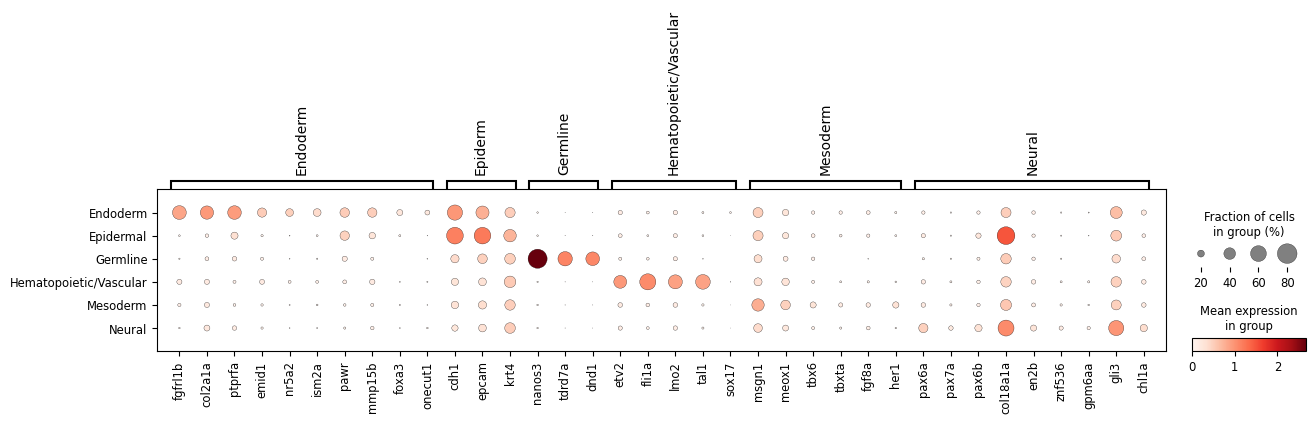

In [41]:
# sc.pl.dotplot(adata, refined_marker_genes, groupby="lineage")

## [updated] compute the marker genes from each tissue (wilcoxon)

In [61]:
sc.tl.rank_genes_groups(adata, groupby="tissue", method = "wilcoxon")

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a fu

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided vi

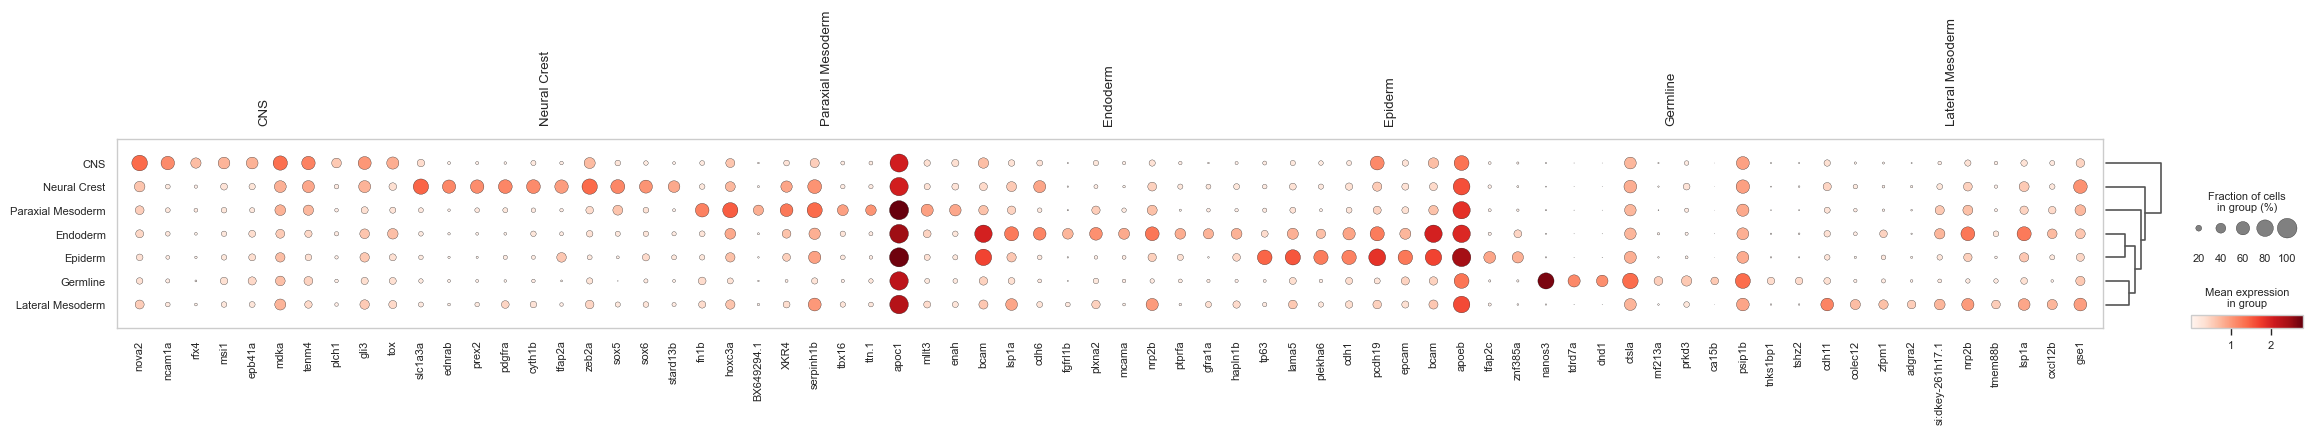

In [75]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=10, save="_tissues_wilcoxon.pdf")

In [119]:
refined_marker_genes = {
    "CNS": ["nova2", "ncam1a", "pax6a"],
    "Endoderm": ["fgfrl1b", "plxna2", "mcama"], #"gata6", "sox17", "sox32", "fgfrl1b", "onecut1", "hnf1ba", "nr5a2", "cdh17"],
    "Epiderm": ["tp63", "epcam", "cdh1"], #, "krt4", "krt8","cldnb", "krtt1c19e", "col17a1b"],
    "Germline": ["nanos3", "dnd1", "tdrd7a"], # "buc", "dazl", "piwil1"],
    "Lateral Mesoderm": ["cdh11", "colec12", "adgra2"],
    "Neural Crest": ["slc1a3a", "ednrab", "prex2", "pdgfra"],
    "Paraxial Mesoderm": ["fn1b","tbx16","msgn1","meox1"],#["myod1", "msgn1", "tbx6", "meox1", "myf5"],
}

In [116]:
marker_genes_ML = {
    "CNS": ["nova2", "sox2", "pax6b", "sox19a"],
    "Endoderm": ["foxa3", "anxa4"], #"gata6", "sox17", "sox32", "fgfrl1b", "onecut1", "hnf1ba", "nr5a2", "cdh17"],
    "Epiderm": ["tp63", "epcam", "cdh1"], #, "krt4", "krt8","cldnb", "krtt1c19e", "col17a1b"],
    "Germline": ["nanos3", "dnd1", "tdrd7a"], # "buc", "dazl", "piwil1"],
    "Lateral Mesoderm": ["cdh11", "colec12", "adgra2"],
    "Neural Crest": ["sox10", "ednrab", "crestin"],
    "Paraxial Mesoderm": ["tbxta","tbx16","msgn1","meox1"],#["myod1", "msgn1", "tbx6", "meox1", "myf5"],
}

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided vi

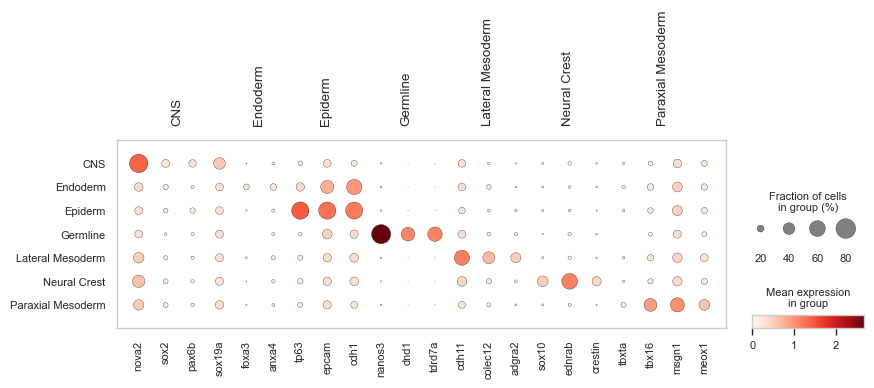

In [118]:
sc.pl.dotplot(adata, var_names=marker_genes_ML, groupby="tissue")

In [72]:
# refined_marker_genes = {
#     "CNS": ["neurog1", "neurod4", "neurod1", "gpm6aa", "pax6a", "pax6b", "gli3", "en2b", "epha4a", "rfx4", "chl1a", "znf536"],
    
#     "Neural Crest": ["foxd3", "tfap2a", "sox10", "prdm1a", "id2a", "snai1b"],
    
#     "Paraxial Mesoderm": ["myod1", "msgn1", "tbx6", "meox1", "tbxta", "her1", "ripply1", "myf5"],
    
#     "Endoderm": ["foxa3", "gata6", "sox17", "sox32", "fgfrl1b", "onecut1", "hnf1ba", "nr5a2", "cdh17"],
    
#     "Epiderm": ["tp63", "krt4", "krt8", "epcam", "cdh1", "cldnb", "krtt1c19e", "col17a1b"],
    
#     "Germline": ["ddx4", "nanos3", "dnd1", "tdrd7a", "buc", "dazl", "piwil1"],
    
#     "Lateral Mesoderm": ["spry4", "tbx5a", "slc4a1a"]
# }

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided vi

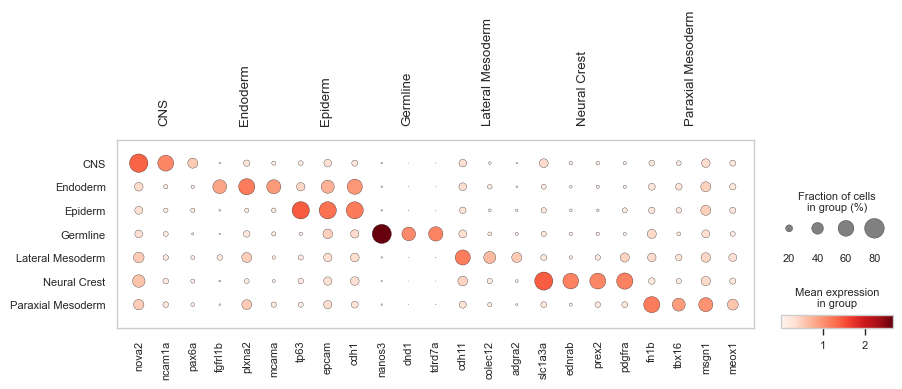

In [115]:
sc.pl.dotplot(adata, var_names = refined_marker_genes, groupby="tissue", save="tissue_selected_markers.pdf")

In [88]:
# import the gene activity matrix (ATAC)
adata_ga = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_gene_activity.h5ad")
adata_ga

AnnData object with n_obs × n_vars = 95196 × 25032
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'prediction.score.Lateral_Mesoderm', 'prediction.score.Neural_Crest', 'prediction.score.Somites', 'prediction.score.Epidermal', 'prediction.score.Neural_Anterior', 'prediction.score.Neural_Posterior', 'prediction.score.Endoderm', 'prediction.score.PSM', 'prediction.score.Differentiating_Neurons', 'prediction.score.Adaxial_Cells', 'prediction.score.NMPs', 'prediction.score.Notochord', 'prediction.score.Muscle', 'prediction.score.unassigned', 'prediction.score.max', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFe

In [90]:
adata_ga = adata_ga[adata_ga.obs_names.isin(adata.obs_names)]
adata_ga

View of AnnData object with n_obs × n_vars = 94562 × 25032
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'prediction.score.Lateral_Mesoderm', 'prediction.score.Neural_Crest', 'prediction.score.Somites', 'prediction.score.Epidermal', 'prediction.score.Neural_Anterior', 'prediction.score.Neural_Posterior', 'prediction.score.Endoderm', 'prediction.score.PSM', 'prediction.score.Differentiating_Neurons', 'prediction.score.Adaxial_Cells', 'prediction.score.NMPs', 'prediction.score.Notochord', 'prediction.score.Muscle', 'prediction.score.unassigned', 'prediction.score.max', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrate

In [92]:
adata_ga.obs_names.map(adata.obs["tissue"])

CategoricalIndex(['Epiderm', 'Lateral Mesoderm', 'CNS', 'CNS', 'CNS', 'CNS',
                  'Neural Crest', 'Paraxial Mesoderm', 'CNS', 'CNS',
                  ...
                  'Epiderm', 'Lateral Mesoderm', 'Paraxial Mesoderm',
                  'Endoderm', 'Lateral Mesoderm', 'Paraxial Mesoderm',
                  'Lateral Mesoderm', 'CNS', 'Endoderm', 'Paraxial Mesoderm'],
                 categories=['CNS', 'Endoderm', 'Epiderm', 'Germline', 'Lateral Mesoderm', 'Neural Crest', 'Paraxial Mesoderm'], ordered=False, dtype='category', length=94562)

In [101]:
# copy over the tissue annotation
adata_ga.obs["tissue"] = adata_ga.obs_names.map(adata.obs["tissue"])
adata_ga

AnnData object with n_obs × n_vars = 94562 × 25032
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'prediction.score.Lateral_Mesoderm', 'prediction.score.Neural_Crest', 'prediction.score.Somites', 'prediction.score.Epidermal', 'prediction.score.Neural_Anterior', 'prediction.score.Neural_Posterior', 'prediction.score.Endoderm', 'prediction.score.PSM', 'prediction.score.Differentiating_Neurons', 'prediction.score.Adaxial_Cells', 'prediction.score.NMPs', 'prediction.score.Notochord', 'prediction.score.Muscle', 'prediction.score.unassigned', 'prediction.score.max', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFe

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


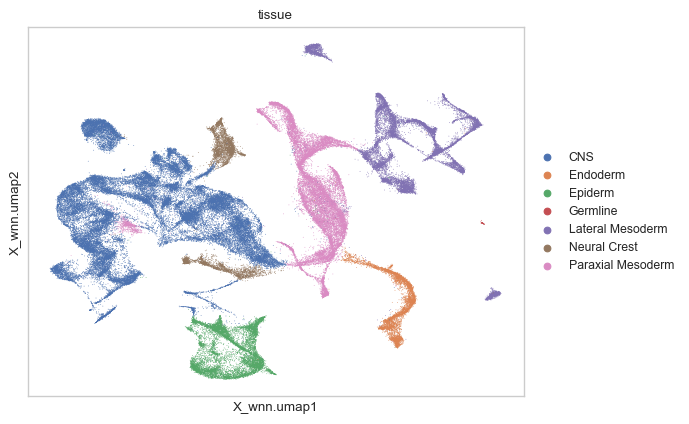

In [102]:
sc.pl.embedding(adata_ga, basis="X_wnn.umap", color="tissue")

In [109]:
np.sum(np.expm1(adata_ga.X.todense()),1)

matrix([[10000.],
        [10000.],
        [10000.],
        ...,
        [10000.],
        [10000.],
        [10000.]])

In [111]:
adata_ga.raw = adata_ga.copy()

/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/hpc/user_apps/data.science/conda_envs/single-cell-base/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided vi

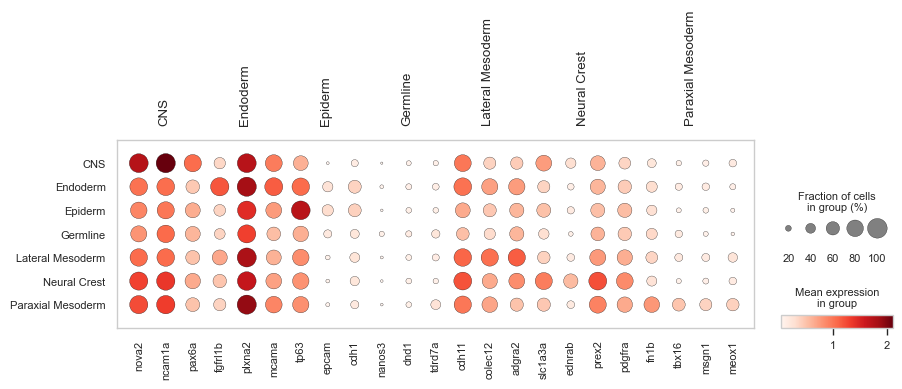

In [120]:
sc.pl.dotplot(adata_ga, var_names = refined_marker_genes, groupby="tissue", save="_gene_activity_tissue_selected_markers.pdf")

In [122]:
# export the metadata (obs) - with tissue/lineage annotations
adata.obs.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/master_obj_obs.csv")